Report Classification

Menggunakan device: cpu
Berhasil memuat model 'model_monyet_kera.pth'.
Berhasil memuat dataset validasi. Total gambar: 1386
Kelas yang dideteksi: ['kera', 'monyet']

Sedang menghitung prediksi model terhadap dataset...


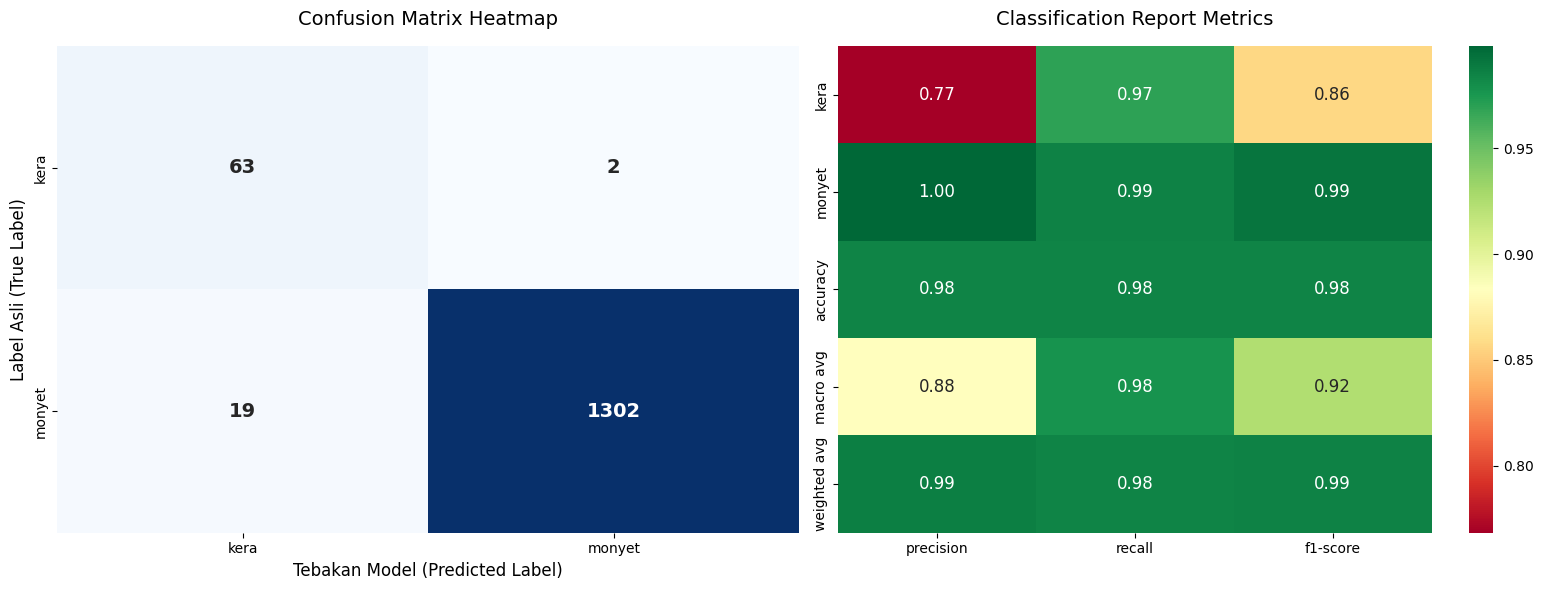

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

model = models.resnet34()
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

model.load_state_dict(torch.load('model_monyet_kera.pth', map_location=device))
model = model.to(device)
print("Berhasil memuat model 'model_monyet_kera.pth'.")

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

try:
    val_dataset = ImageFolder(root='Dataset/val', transform=val_transform)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    print(f"Berhasil memuat dataset validasi. Total gambar: {len(val_dataset)}")
    print(f"Kelas yang dideteksi: {val_dataset.classes}")  # Otomatis ['kera', 'monyet']
except FileNotFoundError:
    print("ERROR: Folder 'Dataset/val' tidak ditemukan. Silakan sesuaikan jalur root folder dataset Anda!")

model.eval()

y_true = []
y_pred = []

print("\nSedang menghitung prediksi model terhadap dataset...")

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

target_names = ['kera', 'monyet']

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=target_names, yticklabels=target_names, ax=ax[0],
            annot_kws={"size": 14, "weight": "bold"})
ax[0].set_title('Confusion Matrix Heatmap', fontsize=14, pad=15)
ax[0].set_ylabel('Label Asli (True Label)', fontsize=12)
ax[0].set_xlabel('Tebakan Model (Predicted Label)', fontsize=12)

report_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)

report_df = pd.DataFrame(report_dict).iloc[:-1, :].T 

sns.heatmap(report_df, annot=True, cmap='RdYlGn', fmt='.2f', cbar=True, ax=ax[1],
            annot_kws={"size": 12})
ax[1].set_title('Classification Report Metrics', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

Loss Classification Predictions

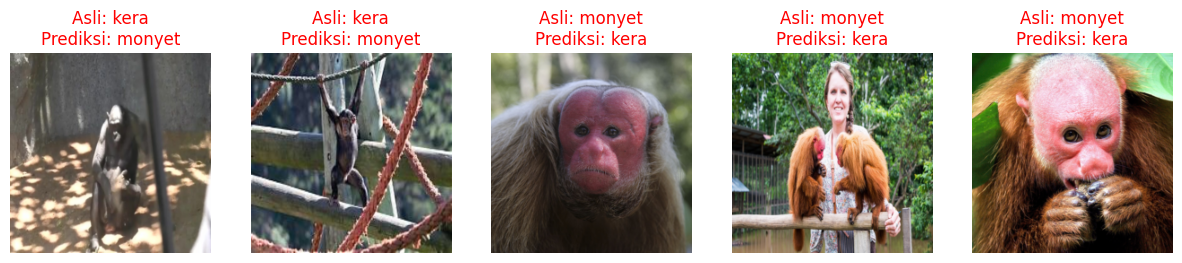

In [2]:
import matplotlib.pyplot as plt

model.eval()
salah_tebak = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        for i in range(len(labels)):
            if preds[i] != labels[i]:
                salah_tebak.append((images[i].cpu(), labels[i].item(), preds[i].item()))

plt.figure(figsize=(15, 5))
for idx, (img, true_lbl, pred_lbl) in enumerate(salah_tebak[:5]):
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
    
    plt.subplot(1, 5, idx + 1)
    plt.imshow(img)
    plt.title(f"Asli: {target_names[true_lbl]}\nPrediksi: {target_names[pred_lbl]}", color='red')
    plt.axis('off')
plt.show()

Graph Accuration

Berhasil memuat history training! Total epoch yang terdeteksi: 20


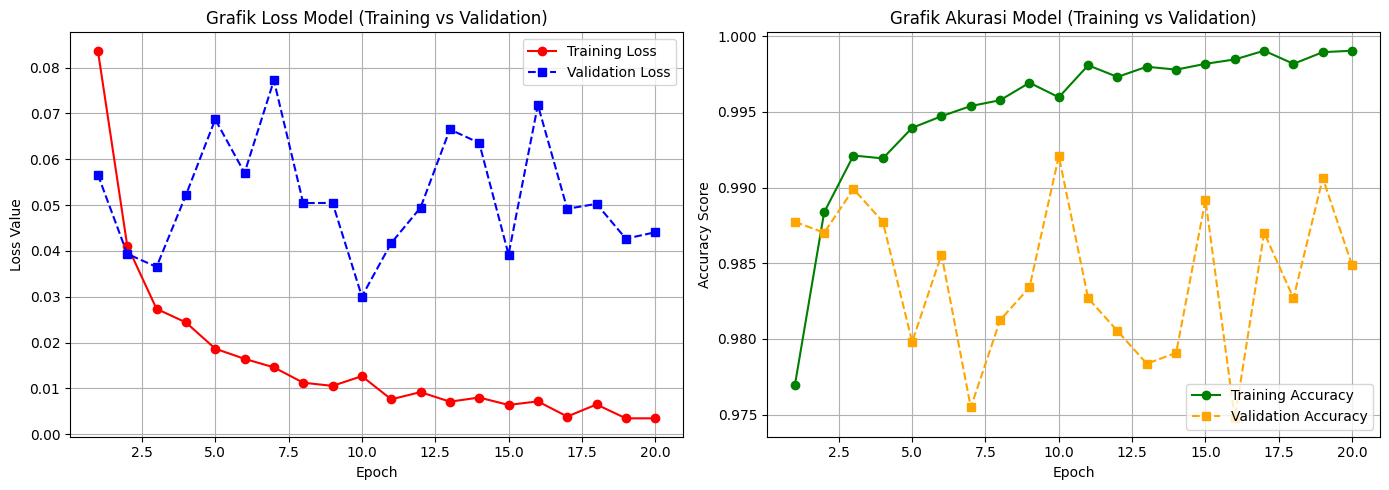

In [3]:
import numpy as np
import matplotlib.pyplot as plt

try:
    history = np.load('training_history.npy', allow_pickle=True).item()
    num_epochs = len(history['train_loss'])
    epochs_range = range(1, num_epochs + 1)
    print(f"Berhasil memuat history training! Total epoch yang terdeteksi: {num_epochs}")
    
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Training Loss', color='red', marker='o')
    plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='blue', linestyle='--', marker='s')
    plt.title('Grafik Loss Model (Training vs Validation)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss Value')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Training Accuracy', color='green', marker='o')
    plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', color='orange', linestyle='--', marker='s')
    plt.title('Grafik Akurasi Model (Training vs Validation)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy Score')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("ERROR: File 'training_history.npy' tidak ditemukan!")
    print("Silakan jalankan file 'train.py' terlebih dahulu di terminal untuk menghasilkan data training!")